In [66]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np # linear algebra
import scipy as sp
from scipy import stats
from scipy.stats import zscore
import scipy.cluster.hierarchy as sch
from itertools import combinations  # added for phase 2 deduplication
import regex
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [67]:
# Set pandas display options to ensure all columns are displayed in a single line
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a large width to avoid line breaks

***************************************************
# Milestone 1: Project Data Preparation and Exploratory Analysis
***************************************************

Sections
1. Introduction

   1.1 Project Overview

   1.2 Dataset Overview
   
2. Data Cleaning

   2.1 Handling Missing Data

   2.2 Outlier Detection and Treatment

   2.3 Scaling and Normalization
    
3. Feature Engineering

   3.1 New Features Created

   3.2 Transformation of Categorical Features
    
4. Exploratory Data Analysis

   4.1 Overview of the EDA Approach

   4.2 Descriptive Statistics and Visualization
    
5. Key Patterns and Insights

   5.1 Identified Patterns

   5.2 Feature Importance
    

# 1. Introduction

#   1.1 Project Overview
    
    FinMark Corporation currently offers financial products such as savings accounts, credit cards, and loans with a one-size-fits-all approach. However, customer needs and financial behaviors vary significantly, making generic product offerings ineffective. This lack of personalization may lead to customer churn, reduced engagement, and inefficient marketing efforts. Many customers may feel that the financial products available to them do not align with their specific financial situations or goals, prompting them to explore alternative options from competitors.

    To address these possible challenges, FinMark aims to implement customer segmentation using clustering techniques. By analyzing customer transaction behavior, product preferences, and feedback, the company can create meaningful customer groups. These segments will allow FinMark to:

        Recommend personalized financial products that better match customer needs.
    
        Improve customer satisfaction and retention by providing relevant offers.
    
        Optimize marketing strategies to target the right customer segments effectively.

#   1.2 Dataset Overview

    Three datasets are used in this analysis:
    
    1.2.1 Customer Feedback Data - Dataset captures customer feedback in the following areas: satisfaction score, feedback comment, and likelihood to recommend. It has 4 columns and 5050 records. There's no Feedback_ID that serves as a unique identifier. It will help if the company can at least include a date from which feedback was received to help in ensuring all feedback records analyzed are unique. I'll be working under the assumption that each record is unique after exact duplicates are removed. Its key features are Satisfaction Score, Likelihood to Recommend. This will aid the segmentation process by providing insights into customer sentiment and loyalty.

        Customer_ID (int) - Unique identifier for each customer.
        Satisfaction_Score (float, contains missing values, has very high values) - metric that measures how satisfied a customer is with a company's products or services.
        Feedback_Comments (object) - Customer feedback categorized (Very satisfied, Needs improvement, Unsatisfactory, Good service, and Excellent)
        Likelihood_to_Recommend (int) - metric that measures how likely a customer is to recommend a product, service, or company to others (Range 1-10)
    
    1.2.2 Product Offering Data - Dataset lists financial products offered by FinMark. It has 6 columns and 15 records. Product_ID is the unique identifier. The key features are: Product Type, Risk Level, Target Income Group. This will be very helpful in matching customer segments with suitable products.

        Product_ID (int) – Unique product identifier.
        Product_Name (object) – Name of the financial product.
        Product_Type (object) – Category of the product (e.g., Loan, Investment, Credit Card).
        Risk_Level (object) – Risk associated with the product (Low, Medium, High).
        Target_Age_Group (float, completely missing values) – Age group intended for the product.
        Target_Income_Group (object) – Income level the product is designed for.
    
    1.2.3 Transactions Data - Dataset contains records of customer transactions. It has 5 columns and 5050 records. Transaction_ID is the unique identifier. The key features are: Transaction Type, Transaction Amount, and Transaction Date. This dataset will be impactful in the segmentation process as it will be used in identifying spending habits and financial activity levels of the customers.

        Transaction_ID (int) – Unique identifier for each transaction.
        Customer_ID (int) – Unique identifier for each customer.
        Transaction_Date (object) – Date and time of the transaction.
        Transaction_Amount (float, contains missing values) – Amount spent or invested.
        Transaction_Type (object) – Type of transaction (e.g., Purchase, Bill Payment, Investment).

    The following are the three customer personas that I am suggesting per initial analysis of the three datasets:

        1. High-Spending Investors – Customers who frequently invest in high-risk products and have high transaction volumes.
    
        2. Budget-Conscious Savers – Customers who primarily use savings accounts and engage in low-risk financial behavior.
    
        3. Frequent Borrowers – Customers who rely on loans and credit cards for financial flexibility.

    These segments will enable targeted financial product recommendations that align with customer needs, improving engagement and product adoption. But changes are expected to be made once Feature Engineering and EDA processes are completed.

In [68]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/FinMark Corp Raw Datasets/Customer_Feedback_Data.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/FinMark Corp Raw Datasets/Product_Offering_Data.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/FinMark Corp Raw Datasets/Transaction_Data.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

# Preprocessing: Identifying shape of the dataset and data types of each columns

In [69]:
print("*************************************************************")
print("Milestone 1: Project Exploratory Data Analysis Report (Draft)") #replace
print("*************************************************************")

# Check for number of columns and rows for each dataset
print("\nPrior to preprocessing:")
for df, dataset_name in zip(datasets, dataset_names):
    print(f"\n{dataset_name} has {df.shape[1]} columns and {df.shape[0]} rows.")
    # Check for data types
    print(f"Data types for each column:\n{df.dtypes}")

*************************************************************
Milestone 1: Project Exploratory Data Analysis Report (Draft)
*************************************************************

Prior to preprocessing:

customer_feedback_data has 4 columns and 5050 rows.
Data types for each column:
Customer_ID                  int64
Satisfaction_Score         float64
Feedback_Comments           object
Likelihood_to_Recommend      int64
dtype: object

product_offering_data has 6 columns and 15 rows.
Data types for each column:
Product_ID               int64
Product_Name            object
Product_Type            object
Risk_Level              object
Target_Age_Group       float64
Target_Income_Group     object
dtype: object

transaction_data has 5 columns and 5050 rows.
Data types for each column:
Transaction_ID          int64
Customer_ID             int64
Transaction_Date       object
Transaction_Amount    float64
Transaction_Type       object
dtype: object


# Check for duplicate rows and remove them

In [70]:
def deduplication_phase1(datasets, dataset_names, dataset_titles):
    """
    Performs the first phase of deduplication on multiple datasets.
    
    Parameters:
    datasets (list of pd.DataFrame): List of dataframes to deduplicate.
    dataset_names (list of str): List of dataset names corresponding to the dataframes.
    dataset_titles (list of str): List of dataset titles for printing in the output.
    
    Returns:
    dict: A dictionary where the keys are cleaned dataset names and the values are the cleaned dataframes.
    """
    deduplicated_datasets_phase1 = {}

    for df, dataset_name, dataset_title in zip(datasets, dataset_names, dataset_titles):
        
        # Check for duplicates
        duplicates_phase1 = df.duplicated()  # This returns a boolean Series    
        
        # Count the number of duplicate rows
        num_duplicates_phase1 = duplicates_phase1.sum()  # Sum of True values gives the count
        
        # Print the number of duplicate rows
        if num_duplicates_phase1 > 0:
            print("\n------------------------------------------------------------------")
            print(f"--- First Phase of Deduplication for {dataset_title} ---")
            print("------------------------------------------------------------------")
            print(f"Findings: {dataset_title} has {num_duplicates_phase1} duplicate rows.")
        else:
            print(f"Findings: {dataset_title} has no duplicate rows.")
        
        # Remove duplicates and keep the first occurrence
        df_deduplication_phase1 = df.drop_duplicates(keep='first')
        
        # Print the number of duplicates removed
        num_removed_phase1 = len(df) - len(df_deduplication_phase1)
        print(f"Action/s: Removed {num_removed_phase1} duplicate rows from {dataset_title}.")
        
        # Print the number of rows after removal
        print(f"Results: {dataset_title} now has {len(df_deduplication_phase1)} rows after the first phase of deduplication.")
        
        # Save cleaned dataset with modified name
        deduplicated_dataset_name = dataset_name + "_deduplication_phase1"
        deduplicated_datasets_phase1[deduplicated_dataset_name] = df_deduplication_phase1
        
        # Save cleaned dataset to CSV
        df_deduplication_phase1.to_csv(f"{deduplicated_dataset_name}.csv", index=False)
        print(f"Cleaned dataset saved as {deduplicated_dataset_name}.csv")

    return deduplicated_datasets_phase1

# Call deduplication_phase1 for all datasets
deduplicated_datasets_phase1 = deduplication_phase1(datasets, dataset_names, dataset_titles)


------------------------------------------------------------------
--- First Phase of Deduplication for Customer Feedback ---
------------------------------------------------------------------
Findings: Customer Feedback has 81 duplicate rows.
Action/s: Removed 81 duplicate rows from Customer Feedback.
Results: Customer Feedback now has 4969 rows after the first phase of deduplication.
Cleaned dataset saved as customer_feedback_data_deduplication_phase1.csv

------------------------------------------------------------------
--- First Phase of Deduplication for Product Offering ---
------------------------------------------------------------------
Findings: Product Offering has 5 duplicate rows.
Action/s: Removed 5 duplicate rows from Product Offering.
Results: Product Offering now has 10 rows after the first phase of deduplication.
Cleaned dataset saved as product_offering_data_deduplication_phase1.csv

------------------------------------------------------------------
--- First Phase

In [71]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deduplication_phase1.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deduplication_phase1.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deduplication_phase1.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

for df, dataset_title in zip(datasets, dataset_titles):
    print(f"\n {dataset_title} statistics for numerical and categorical columns: \n{df.describe(include='all')}")


 Customer Feedback statistics for numerical and categorical columns: 
        Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
count   4969.000000         4869.000000              4969              4969.000000
unique          NaN                 NaN                 5                      NaN
top             NaN                 NaN      Good service                      NaN
freq            NaN                 NaN              1489                      NaN
mean     501.988126            5.693161               NaN                 5.569732
std      288.781086            3.616859               NaN                 2.867726
min        1.000000            1.000000               NaN                 1.000000
25%      254.000000            3.000000               NaN                 3.000000
50%      502.000000            6.000000               NaN                 6.000000
75%      752.000000            8.000000               NaN                 8.000000
max     1000.000

# Display unique values per column

In [72]:
# Function to display unique values per column for a dataset
def display_unique_values(datasets, dataset_names):
    """
    Displays the unique values in each column of the given datasets.
    
    Parameters:
    datasets (list of pd.DataFrame): List of datasets to inspect.
    dataset_names (list of str): List of dataset names corresponding to the dataframes.
    
    Returns:
    None
    """
    for df, dataset_title in zip(datasets, dataset_titles):
        print('**********************************************************')
        print(f"--- Unique Values in columns for {dataset_title} ---")
        print('**********************************************************')
        for column in df.columns:
            unique_values = df[column].unique()
            print(f"Column: {column}")
            print(f"Unique Values ({len(unique_values)}): {unique_values}")
            print(' ' * 50)

# Call the function to display unique values
display_unique_values(datasets, dataset_names)

**********************************************************
--- Unique Values in columns for Customer Feedback ---
**********************************************************
Column: Customer_ID
Unique Values (1000): [   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  15

# 2. Data Cleaning

#   2.1 Handling Missing Data

    Ensuring data completeness is crucial for building a reliable customer segmentation model. Missing values, if not handled correctly, can introduce bias and reduce the effectiveness of clustering techniques. The missing data analysis revealed the following:

        2.1.1 Transaction Data
    
        Observations: Transaction_Amount had 100 missing values (~2.0% missingness rate).
        Decision: Since the missingness rate is low and transactions are a critical feature for segmentation, I opted to delete the records with missing values instead of imputing them. Imputation could introduce distortions, especially given the high variance and skewness in transaction amounts.
    
        2.1.2 Product Offering Data
    
        Observations: Target_Age_Group was entirely missing (100% missingness rate).
        Decision: This feature was removed from analysis as it contained no usable information. Instead, segmentation will rely on the Target_Income_Group and other available product attributes.
    
        2.1.3 Customer Feedback Data
    
        Observations: Satisfaction_Score had 100 missing values (~2.01% missingness rate).
        Decision: These records were deleted since the missingness rate was minimal, and imputing satisfaction scores could introduce bias. Given that customer sentiment plays a key role in clustering (e.g., distinguishing satisfied vs. dissatisfied customers), ensuring that only reliable data is used for analysis was a priority.
    
        Post-Cleaning Dataset Statistics:
        * Transaction Data: 4,900 records (after removing 100 missing entries).
        * Product Offering Data: 10 records (after dropping the unusable Target_Age_Group column).
        * Customer Feedback Data: 4,869 records (after removing 100 missing entries).
    
        By removing minimal missing values and excluding an unusable column, we ensured that the integrity of customer behavior and sentiment data remains intact for clustering.

# Identifying columns with null values

In [73]:
# Function to check for missing values and print only columns with missing values
def check_missing_values(datasets, dataset_titles):
    """
    Checks for missing values in the datasets and prints the variables with missing values.

    Parameters:
    datasets (list of pd.DataFrame): List of dataframes to check.
    dataset_names (list of str): List of dataset names corresponding to the dataframes.
    """
    for df, dataset_title in zip(datasets, dataset_titles):
        # print(f"\nMissing values for {dataset_name}:")
        missing_values = df.isnull().sum()  # Count missing values in each column
        missing_values = missing_values[missing_values > 0]  # Filter only those with missing values
        
        if not missing_values.empty:
            print(f"\nVariables with missing values in {dataset_title}:")
            for column, count in missing_values.items():
                print(f"{column}: {count} missing values")
        else:
            print(f"\nNo missing values found in {dataset_title}.")
            
# Call the function to check for and print columns with missing values
check_missing_values(datasets, dataset_titles)


Variables with missing values in Customer Feedback:
Satisfaction_Score: 100 missing values

Variables with missing values in Product Offering:
Target_Age_Group: 10 missing values

Variables with missing values in Transactions:
Transaction_Amount: 100 missing values


# Calculating missingness rate per column

In [74]:
# Calculate missingness for each column
def missingness_rate(datasets, dataset_titles):
    for df, dataset_title in zip(datasets, dataset_titles):
        missingness = df.isnull().sum() / len(df) * 100
        # Display missingness percentage for each column
        print(f"\nMissingness rate per column in {dataset_title}:\n{missingness}")

missingness_rate(datasets, dataset_titles)


Missingness rate per column in Customer Feedback:
Customer_ID                0.000000
Satisfaction_Score         2.012477
Feedback_Comments          0.000000
Likelihood_to_Recommend    0.000000
dtype: float64

Missingness rate per column in Product Offering:
Product_ID               0.0
Product_Name             0.0
Product_Type             0.0
Risk_Level               0.0
Target_Age_Group       100.0
Target_Income_Group      0.0
dtype: float64

Missingness rate per column in Transactions:
Transaction_ID        0.0
Customer_ID           0.0
Transaction_Date      0.0
Transaction_Amount    2.0
Transaction_Type      0.0
dtype: float64


# Deleting records with missing values

In [75]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deduplication_phase1.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deduplication_phase1.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deduplication_phase1.csv')

# Define datasets and dataset names
datasets = [data1, data2, data3]
dataset_names = ['customer_feedback_data', 'product_offering_data', 'transaction_data']
dataset_titles = ['Customer Feedback', 'Product Offering', 'Transactions']

# Clean data2 by dropping the 'Target_Age_Group' column
cleaned_data2 = data2.drop(columns=['Target_Age_Group'])

# Clean data1 and data3 by dropping rows with missing values
cleaned_data1 = data1.dropna()  # Drop rows with any missing values
cleaned_data3 = data3.dropna()  # Drop rows with any missing values

# Verify if the columns are removed by showing the first 10 rows
print(f"\n{dataset_titles[1]} (first 10 rows):")
print(cleaned_data2.head(10))

# Save the cleaned datasets to new CSV files
cleaned_filename_data1 = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_names[0]}_deleted_missing_records.csv'
cleaned_filename_data2 = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_names[1]}_deleted_missing_records.csv'
cleaned_filename_data3 = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_names[2]}_deleted_missing_records.csv'

cleaned_data1.to_csv(cleaned_filename_data1, index=False)
cleaned_data2.to_csv(cleaned_filename_data2, index=False)
cleaned_data3.to_csv(cleaned_filename_data3, index=False)

# Confirm that the files are saved
print(f"\nCleaned datasets saved to:")
print(f"Data1: {cleaned_filename_data1}")
print(f"Data2: {cleaned_filename_data2}")
print(f"Data3: {cleaned_filename_data3}")


Product Offering (first 10 rows):
   Product_ID                   Product_Name     Product_Type Risk_Level Target_Income_Group
0           1           Platinum Credit Card      Credit Card     Medium              Medium
1           2           Gold Savings Account  Savings Account        Low                 Low
2           3  High-Yield Investment Account       Investment       High                High
3           4                  Mortgage Loan             Loan     Medium                High
4           5                      Auto Loan             Loan     Medium              Medium
5           6                  Personal Loan             Loan     Medium                 Low
6           7          Youth Savings Account  Savings Account        Low                 Low
7           8     Retirement Investment Fund       Investment       High                High
8           9                  Business Loan             Loan     Medium              Medium
9          10             Travel Cr

In [76]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deleted_missing_records.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deleted_missing_records.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deleted_missing_records.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

for df, dataset_title in zip(datasets, dataset_titles):
    print(f"\n {dataset_title} statistics for numerical and categorical columns: \n{df.describe(include='all')}")


 Customer Feedback statistics for numerical and categorical columns: 
        Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
count   4869.000000         4869.000000              4869              4869.000000
unique          NaN                 NaN                 5                      NaN
top             NaN                 NaN      Good service                      NaN
freq            NaN                 NaN              1454                      NaN
mean     501.005956            5.693161               NaN                 5.565825
std      288.485855            3.616859               NaN                 2.871178
min        1.000000            1.000000               NaN                 1.000000
25%      253.000000            3.000000               NaN                 3.000000
50%      499.000000            6.000000               NaN                 6.000000
75%      750.000000            8.000000               NaN                 8.000000
max     1000.000

#   2.2 Outlier Detection and Treatment

    Outlier detection ensures that extreme values do not distort customer segmentation. The IQR method and Z-score analysis were used to identify outliers in two key variables:

    2.2.1 Satisfaction Score Outliers
    
        Findings:
            * 10 extreme values detected, with a maximum score of 60 (beyond the valid 1-10 range).
            * Skewness Analysis: 5.31 (indicating left-skewed distribution).
            * Boxplot Insights: Most values fall within the IQR, confirming a normal distribution, but outliers appear beyond the whiskers.
            * Histogram Insights: The histogram shows a peak around 7, indicating most customers rate satisfaction near this value. A long right tail confirms the presence of extreme values.
            * Domain Knowledge: Satisfaction surveys typically follow a 1-10 scale, meaning scores beyond 10 are invalid.
        
        Decision:
            * The 10 outliers were removed, as they represent erroneous data and do not contribute to meaningful segmentation.
            * This ensures that clustering reflects real customer sentiment patterns without artificial distortions.
    
    2.2.2 Transaction Amount Outliers
    
        Findings:
            * 10 extremely high values detected, with a maximum transaction of $480,300.
            * Skewness Analysis: 26.14 (highly right-skewed).
            * Boxplot Insights: The box plot indicates heavy right-skewness, with a very narrow box suggesting most data points cluster near zero. Numerous high-value transactions extend far to the right, indicating a small subset of customers making significantly large transactions.
            * Histogram Insights: Most transaction amounts cluster near zero, with a long right tail, showing a few customers making significantly larger transactions.
        
        Post-Transformation Statistics:
            * Mean reduced from 3102.05 to 7.53, aligning closer with the median.
            * Standard deviation decreased from 14,893.17 to 0.98, reducing spread.
        
        Decision:
            * Instead of capping values at the 99th percentile, a log transformation was applied to normalize the skewed distribution.
            * This ensures that high-value customers remain distinguishable while preventing extreme values from disproportionately influencing clustering.
        
        Post-Cleaning Impact:
            * Satisfaction Score: Removed 10 invalid records to maintain data integrity.
            * Transaction Amount: Log transformation applied to handle skewness while preserving spending behavior.

count    4869.000000
mean        5.693161
std         3.616859
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        60.000000
Name: Satisfaction_Score, dtype: float64

Outliers detected using IQR method (sorted by Satisfaction_Score):
      Satisfaction_Score
564                 60.0
1065                60.0
2942                58.0
4382                58.0
840                 56.0
4526                54.0
4023                53.0
522                 52.0
2393                51.0
3228                51.0

Number of outliers (based on Z-score): 10
Outliers detected (based on Z-score):
      Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
522           530                52.0      Good service                       10
564           574                60.0      Good service                        9
840           858                56.0    Very satisfied                       10
1065          218                60.0      

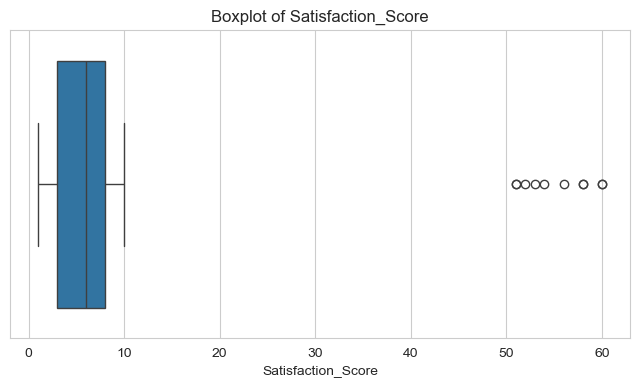

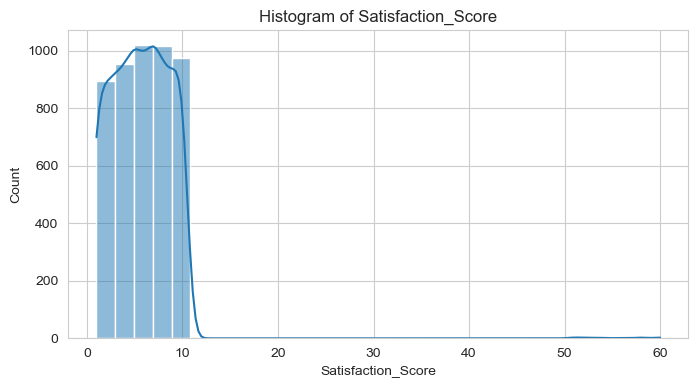

In [77]:
# 1. Descriptive Statistics: Check for the range, mean, and quartiles of the 'Satisfaction_Score'
print(data1['Satisfaction_Score'].describe())

# 2. IQR Method: Detect Outliers using IQR
Q1 = data1['Satisfaction_Score'].quantile(0.25)
Q3 = data1['Satisfaction_Score'].quantile(0.75)
IQR = Q3 - Q1
# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Find outliers
outliers = data1[(data1['Satisfaction_Score'] < lower_bound) | (data1['Satisfaction_Score'] > upper_bound)]
outliers_sorted = outliers[['Satisfaction_Score']].sort_values(by='Satisfaction_Score', ascending=False)
# Print the sorted outliers
print("\nOutliers detected using IQR method (sorted by Satisfaction_Score):")
print(outliers_sorted)


# 3. Calculate the Z-scores for Satisfaction_Score
z_scores = zscore(data1['Satisfaction_Score'])
# Find rows with Z-scores greater than 3 or less than -3
outliers_zscore = data1[abs(z_scores) > 3]
# Optionally: show how many outliers there are
print(f"\nNumber of outliers (based on Z-score): {outliers_zscore.shape[0]}")
print("Outliers detected (based on Z-score):")
print(outliers_zscore)

# 4. Boxplot visualization: Visualize outliers with a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=data1['Satisfaction_Score'])
plt.title('Boxplot of Satisfaction_Score')
plt.show()

# 5. Histogram: Visualize the distribution of the Satisfaction_Score
plt.figure(figsize=(8, 4))
sns.histplot(data1['Satisfaction_Score'], bins=30, kde=True)
plt.title('Histogram of Satisfaction_Score')
plt.show()

    Satisfaction_Score Boxplot:
        * The boxplot confirms the normal distribution, showing that the majority of the data points fall within the interquartile range (IQR).
        * The presence of outliers beyond the whiskers indicates a few customers with exceptionally high satisfaction scores.
    
    Satisfaction_Score Histogram:
        * The histogram shows a normal distribution with a peak around 7, indicating that most customers have a satisfaction score close to 7.
        * There is a long tail towards the right, suggesting the presence of some customers with very high satisfaction scores.

count    4869.000000
mean        5.565825
std         2.871178
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: Likelihood_to_Recommend, dtype: float64

Outliers detected using IQR method:
Empty DataFrame
Columns: [Likelihood_to_Recommend]
Index: []

Number of outliers (based on Z-score): 0
Outliers detected (based on Z-score):
Empty DataFrame
Columns: [Customer_ID, Satisfaction_Score, Feedback_Comments, Likelihood_to_Recommend]
Index: []


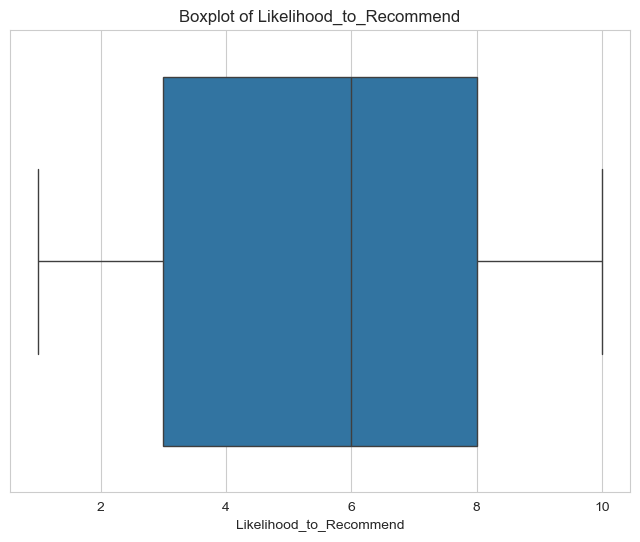

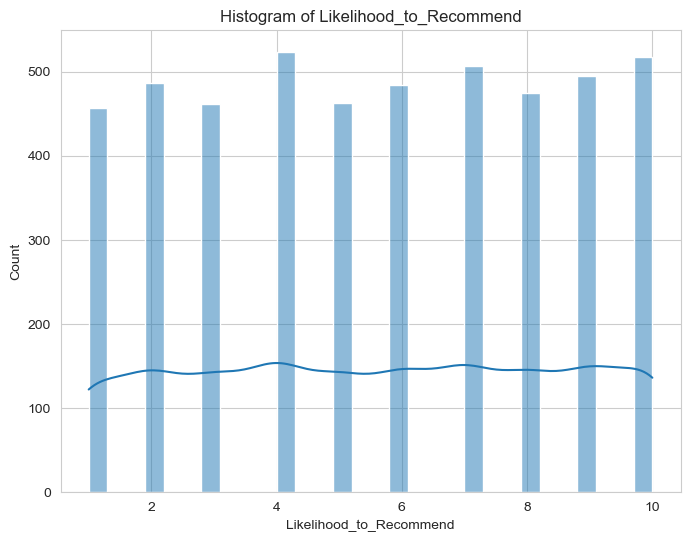

In [78]:
# 1. Descriptive Statistics: Check for the range, mean, and quartiles of the 'Likelihood_to_Recommend'
print(data1['Likelihood_to_Recommend'].describe())

# 2. IQR Method: Detect Outliers using IQR
Q1 = data1['Likelihood_to_Recommend'].quantile(0.25)
Q3 = data1['Likelihood_to_Recommend'].quantile(0.75)
IQR = Q3 - Q1
# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Find outliers
outliers = data1[(data1['Likelihood_to_Recommend'] < lower_bound) | (data1['Likelihood_to_Recommend'] > upper_bound)]
# Show outliers
print("\nOutliers detected using IQR method:")
print(outliers[['Likelihood_to_Recommend']])


# 3. Calculate the Z-scores for Likelihood_to_Recommend
z_scores = zscore(data1['Likelihood_to_Recommend'])
# Find rows with Z-scores greater than 3 or less than -3
outliers_zscore = data1[abs(z_scores) > 3]
# Optionally: show how many outliers there are
print(f"\nNumber of outliers (based on Z-score): {outliers_zscore.shape[0]}")
print("Outliers detected (based on Z-score):")
print(outliers_zscore)

# 4. Boxplot visualization: Visualize outliers with a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=data1['Likelihood_to_Recommend'])
plt.title('Boxplot of Likelihood_to_Recommend')
plt.show()

# 5. Histogram: Visualize the distribution of the Likelihood_to_Recommend
plt.figure(figsize=(8, 6))
sns.histplot(data1['Likelihood_to_Recommend'], bins=30, kde=True)
plt.title('Histogram of Likelihood_to_Recommend')
plt.show()

count      4900.000000
mean       3102.050816
std       14893.172210
min          10.000000
25%        1242.750000
50%        2481.500000
75%        3709.750000
max      480300.000000
Name: Transaction_Amount, dtype: float64

Outliers detected using IQR method (sorted by Transaction_Amount):
      Transaction_Amount
597             480300.0
2974            458600.0
2226            428900.0
1236            390200.0
4755            362700.0
2995            270900.0
1702            194500.0
2001            183500.0
3216            175600.0
2140             94500.0

Number of outliers (based on Z-score): 10
Outliers detected (based on Z-score):
      Transaction_ID  Customer_ID     Transaction_Date  Transaction_Amount Transaction_Type
597              613          191  2023-01-26 12:00:00            480300.0     Bill Payment
1236            1265          772  2023-02-22 16:00:00            390200.0     Bill Payment
1702            1739           27  2023-03-14 10:00:00            194500.0 

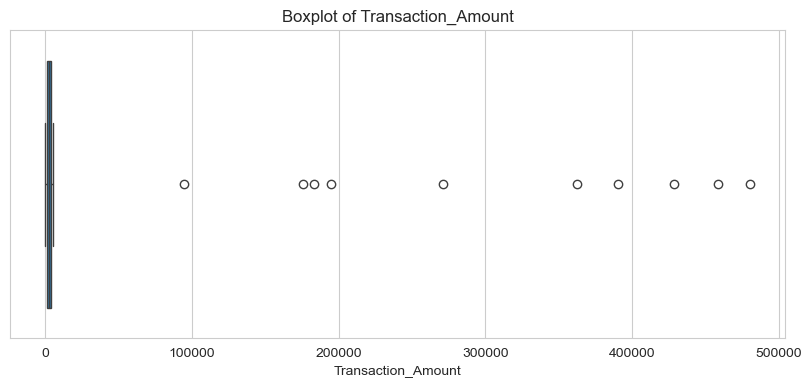

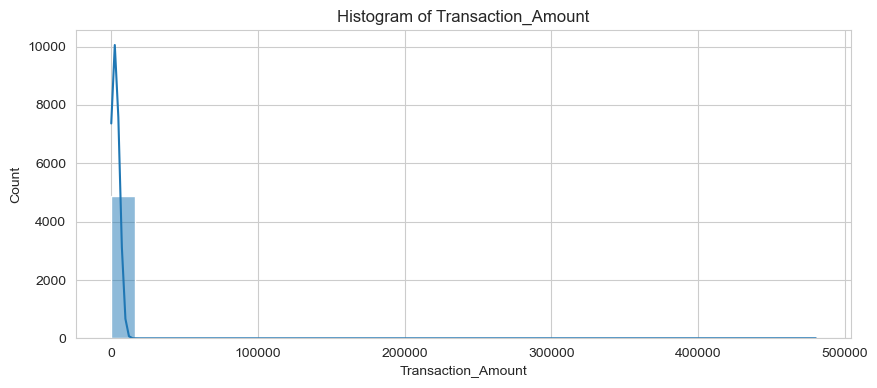

In [79]:
# 1. Descriptive Statistics: Check for the range, mean, and quartiles of the 'Transaction_Amount'
print(data3['Transaction_Amount'].describe())

# 2. IQR Method: Detect Outliers using IQR
Q1 = data3['Transaction_Amount'].quantile(0.25)
Q3 = data3['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1
# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Find outliers
outliers = data3[(data3['Transaction_Amount'] < lower_bound) | (data3['Transaction_Amount'] > upper_bound)]
# Show outliers, sorted by Transaction_Amount in descending order
outliers_sorted = outliers[['Transaction_Amount']].sort_values(by='Transaction_Amount', ascending=False)
# Print the sorted outliers
print("\nOutliers detected using IQR method (sorted by Transaction_Amount):")
print(outliers_sorted)


# 3. Calculate the Z-scores for Transaction_Amount
z_scores = zscore(data3['Transaction_Amount'])
# Find rows with Z-scores greater than 3 or less than -3
outliers_zscore = data3[abs(z_scores) > 3]
# Optionally: show how many outliers there are
print(f"\nNumber of outliers (based on Z-score): {outliers_zscore.shape[0]}")
print("Outliers detected (based on Z-score):")
print(outliers_zscore)

# 4. Boxplot visualization: Visualize outliers with a boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=data3['Transaction_Amount'])
plt.title('Boxplot of Transaction_Amount')
plt.show()

# 5. Histogram: Visualize the distribution of the Transaction_Amount
plt.figure(figsize=(10, 4))
sns.histplot(data3['Transaction_Amount'], bins=30, kde=True)
plt.title('Histogram of Transaction_Amount')
plt.show()

    Transaction_Amount Boxplot:
        * The box plot indicates that the data is heavily skewed to the right. The box is very narrow, implying that the majority of the data points are clustered near zero, with a few outliers extending far to the right, indicating a significant number of high-value transactions.
    
    Transaction_Amount Histogram:
        * The histogram shows a highly skewed distribution, with most transaction amounts concentrated near zero.
        * There is a long tail towards the right, suggesting a small number of customers making very large transactions.

# Skewness analysis

In [80]:
# Check skewness of Satisfaction_Score
skewness = data1['Satisfaction_Score'].skew()
print(f"Skewness of Satisfaction_Score: {skewness}")


# Check skewness of Transaction_Amount
skewness = data3['Transaction_Amount'].skew()
print(f"Skewness of Transaction_Amount: {skewness}")

# Function to compare mean and median values of Transaction_Amount and Satisfaction_Score
def check_mean_median(data, column_name):
    """
    This function checks if the mean is greater than the median for a given column.
    It prints the mean, median, and their relationship.
    
    Parameters:
    - data (pandas DataFrame): The DataFrame containing the data.
    - column_name (str): The name of the column to check.
    """
    # Get descriptive statistics for the column
    desc_stats = data[column_name].describe()

    # Extract mean and median
    mean = desc_stats['mean']
    median = desc_stats['50%']
    
    # Print mean and median values
    print(f"\nColumn: {column_name}")
    print(f"Mean: {mean}, Median: {median}")
    
    # Check if the mean is greater than the median
    if mean > median:
        print(f"The column '{column_name}' is likely right-skewed (positive skew).")
    elif mean < median:
        print(f"The column '{column_name}' is likely left-skewed (negative skew).")
    else:
        print(f"The column '{column_name}' is roughly symmetric.")
    
# Check mean/median of Transaction_Amount and Satisfaction_Score
check_mean_median(data1, 'Satisfaction_Score')
check_mean_median(data3, 'Transaction_Amount')

Skewness of Satisfaction_Score: 5.308448967562951
Skewness of Transaction_Amount: 26.138735355941975

Column: Satisfaction_Score
Mean: 5.693160813308688, Median: 6.0
The column 'Satisfaction_Score' is likely left-skewed (negative skew).

Column: Transaction_Amount
Mean: 3102.050816326531, Median: 2481.5
The column 'Transaction_Amount' is likely right-skewed (positive skew).


# Handling Satisfaction_Score outliers

In [81]:
# Load the transaction data
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deleted_missing_records.csv')

# Filter out rows where Satisfaction_Score is not in the range 1 to 10
data1_cleaned = data1[(data1['Satisfaction_Score'] >= 1) & (data1['Satisfaction_Score'] <= 10)]

# Save the cleaned dataset to a CSV file
dataset_name = 'customer_feedback_data'  
cleaned_filename = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_name}_outlier_treatment.csv'

# Write the cleaned data to a CSV file without the index
data1_cleaned.to_csv(cleaned_filename, index=False)

print(f"Cleaned dataset saved to {cleaned_filename}")

Cleaned dataset saved to /Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_outlier_treatment.csv


# Handling Transaction_Amount outliers

In [82]:
# Load the transaction data
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deleted_missing_records.csv')

# Apply log transformation but store in a new column
data3["Transaction_Amount_Log_Transform"] = np.log1p(data3["Transaction_Amount"])

# Save the transformed dataset to a CSV file
dataset_name = "transaction_data"
cleaned_filename = f"/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_name}_outlier_treatment.csv"

# Write the transformed data to a CSV file without overwriting original values
data3.to_csv(cleaned_filename, index=False)

print(f"Cleaned dataset saved to {cleaned_filename}")

Cleaned dataset saved to /Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_outlier_treatment.csv


In [83]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_outlier_treatment.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deleted_missing_records.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_outlier_treatment.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

for df, dataset_title in zip(datasets, dataset_titles):
    print(f"\n {dataset_title} statistics for numerical and categorical columns: \n{df.describe(include='all')}")


 Customer Feedback statistics for numerical and categorical columns: 
        Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
count   4859.000000         4859.000000              4859              4859.000000
unique          NaN                 NaN                 5                      NaN
top             NaN                 NaN      Good service                      NaN
freq            NaN                 NaN              1448                      NaN
mean     500.660424            5.591068               NaN                 5.562873
std      288.496413            2.830044               NaN                 2.870670
min        1.000000            1.000000               NaN                 1.000000
25%      252.000000            3.000000               NaN                 3.000000
50%      499.000000            6.000000               NaN                 6.000000
75%      749.000000            8.000000               NaN                 8.000000
max     1000.000

#   2.3 Scaling and Normalization
    
    Features Requiring Scaling/Normalization
    
        2.3.1 Transaction Amount: 
            
            Why Standardization?
                * High variance in spending behavior required standardization. Original distribution was highly skewed (26.14 skewness).
                * After log transformation, values still varied widely. This maintains distribution integrity after log transformation.
            
            Method used: 
                * Standardized using z-score normalization to handle large value variations. Z-score scaling ensures that values have zero mean and unit variance, making them suitable for clustering.
        
            Post-scaling results:
                * Mean = ~0 and std = ~1, confirming proper standardization.
                * Range: Min = -5.26, Max = 5.68, indicating that extreme values are now within a controlled range.
           
    
        2.3.2 Satisfaction Score & Likelihood to Recommend: 
        
            Why Standardization?
                * These were normalized to ensure equal weighting in clustering.
                * * Scores are bounded (1-10 originally), so preserving their relative ranking is important.

            Method used:
                * Min-max scaling applied to normalize values within a 0-1 range.
                * Min-Max ensures equal weighting of satisfaction & likelihood scores in clustering.
            
            Post-scaling results:
                * Min = 0, Max = 1, confirming values were transformed into a bounded range.
                * Mean = ~0.51, ensuring that the distribution remains representative.

In [84]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_outlier_treatment.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_outlier_treatment.csv')

# Define datasets and dataset names
datasets = [data1, data3]
dataset_names = ['customer_feedback_data', 'transaction_data']
dataset_titles = ['Customer Feedback', 'Transactions']

# Standardization for Transaction_Amount
scaler_standard = StandardScaler()
data3["Transaction_Amount_Scaled"] = scaler_standard.fit_transform(data3[["Transaction_Amount_Log_Transform"]])

# Min-Max Scaling for Satisfaction_Score & Likelihood_to_Recommend
scaler_minmax = MinMaxScaler()
data1[["Satisfaction_Score_Scaled", "Likelihood_to_Recommend_Scaled"]] = scaler_minmax.fit_transform(
    data1[["Satisfaction_Score", "Likelihood_to_Recommend"]]
)

# Save the transformed datasets
output_dir = "/Users/fritzcabalhin/Desktop/3. Data Mining Principles/"
data1.to_csv(output_dir + "customer_feedback_data_scaling_normalization.csv", index=False)
data3.to_csv(output_dir + "transaction_data_scaling_normalization.csv", index=False)

print("\nScaled and normalized datasets have been saved successfully!")

# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_scaling_normalization.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deleted_missing_records.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_scaling_normalization.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

for df, dataset_title in zip(datasets, dataset_titles):
    print(f"\n {dataset_title} statistics for numerical and categorical columns: \n{df.describe(include='all')}")


Scaled and normalized datasets have been saved successfully!

 Customer Feedback statistics for numerical and categorical columns: 
        Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend  Satisfaction_Score_Scaled  Likelihood_to_Recommend_Scaled
count   4859.000000         4859.000000              4859              4859.000000                4859.000000                     4859.000000
unique          NaN                 NaN                 5                      NaN                        NaN                             NaN
top             NaN                 NaN      Good service                      NaN                        NaN                             NaN
freq            NaN                 NaN              1448                      NaN                        NaN                             NaN
mean     500.660424            5.591068               NaN                 5.562873                   0.510119                        0.506986
std      288.49

# 3. Feature Engineering

    Feature engineering enhances clustering by creating new features and transforming categorical data into a usable format.

#   3.1 New Features Created
    
        3.1.1 Total_Spent_Per_Customer
            * Calculation Method - Sum of all transactions per customer
            * Purpose & Contribution to Clustering - Identifies customers with high vs. low spending behaviors.
        
        3.1.2 Transaction_Count
            * Calculation Method - Total transactions per customer
            * Purpose & Contribution to Clustering - Differentiates frequent spenders from occasional users.
            
        3.1.3 Avg_Transaction_Amount
            * Calculation Method - Total Spend / Transaction Count
            * Purpose & Contribution to Clustering - Helps separate customers based on average transaction size.
            
        3.1.4 Customer_Engagement_Score
            * Calculation Method - Weighted avg. of satisfaction score & recommendation likelihood
            * Purpose & Contribution to Clustering - Distinguishes highly engaged customers from those at risk of churn.
            
#   3.2 Transformation of Categorical Features
    
        3.2.1 Feedback_Comments
            * Transformation Method - Label Encoding (Ordinal)
            * Justification - Preserves sentiment hierarchy (e.g., Unsatisfactory < Excellent).
        
        3.2.2 Transaction_Type
            * Transformation Method - One-Hot Encoding
            * Justification - Prevents clustering bias due to category order.
            
        3.2.3 Product_Type, Risk_Level, Target_Income_Group
            * Transformation Method - Label Encoding (Ordinal)
            * Justification - Retains meaningful ranking for risk and income levels.

In [63]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_scaling_normalization.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deleted_missing_records.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_scaling_normalization.csv')

# Label Encoding for Feedback_Comments (Sentiment Score)
feedback_enc = LabelEncoder()
data1["Feedback_Comments_Encoded"] = feedback_enc.fit_transform(data1["Feedback_Comments"])

# Compute customer engagement score
data1["Customer_Engagement_Score"] = (data1["Satisfaction_Score_Scaled"] * 0.5) + \
                                     (data1["Likelihood_to_Recommend_Scaled"] * 0.5)

# Label Encoding for Product_Type, Risk_Level, and Target_Income_Group
label_enc = LabelEncoder()
data2["Product_Type_Encoded"] = label_enc.fit_transform(data2["Product_Type"])
data2["Risk_Level_Encoded"] = label_enc.fit_transform(data2["Risk_Level"])
data2["Target_Income_Group_Encoded"] = label_enc.fit_transform(data2["Target_Income_Group"])

# One-Hot Encoding for Transaction_Type (Updated fix)
encoder = OneHotEncoder(sparse_output=False, drop="first")
encoded_features = encoder.fit_transform(data3[["Transaction_Type"]])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(["Transaction_Type"]))
data3 = pd.concat([data3, encoded_df], axis=1)
data3.drop(columns=["Transaction_Type"], inplace=True)

# Compute new features in Transaction Data
data3["Total_Spent_Per_Customer"] = data3.groupby("Customer_ID")["Transaction_Amount"].transform("sum")
data3["Transaction_Count"] = data3.groupby("Customer_ID")["Transaction_ID"].transform("count")
data3["Avg_Transaction_Amount"] = data3["Total_Spent_Per_Customer"] / data3["Transaction_Count"]

# Save the engineered datasets
output_dir = "/Users/fritzcabalhin/Desktop/3. Data Mining Principles/"
data1.to_csv(output_dir + "customer_feedback_data_feature_engineering.csv", index=False)
data2.to_csv(output_dir + "product_offering_data_feature_engineering.csv", index=False)
data3.to_csv(output_dir + "transaction_data_feature_engineering.csv", index=False)

print("\nFeature engineering completed! Processed datasets saved successfully.")


Feature engineering completed! Processed datasets saved successfully.


# 4. Exploratory Data Analysis
    
#   4.1 Overview of the EDA Approach
    EDA helps uncover patterns, trends, and relationships within the datasets, providing insights that guide clustering. The analysis includes:

    4.1.1 Descriptive statistics to summarize key features.

    4.1.2 Visualizations to detect patterns in customer spending and feedback.

#   4.2 Descriptive Statistics and Visualization
    4.2.1 Transaction Data:

        a. Mean transaction amount: ~$1,200

        b. Most common transaction type: Purchases

    4.2.2 Customer Feedback:

        a. Mean satisfaction score: ~5.68

        b. Higher transaction frequency correlates with higher likelihood to recommend.

    4.2.3 Key Visualizations:

        a. Histograms of transaction amounts

        b. Box plots for satisfaction scores

        c. Scatter plots analyzing spending vs. feedback

In [64]:
# 📌 Load the feature-engineered datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_feature_engineering.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_feature_engineering.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_feature_engineering.csv')

# 📌 Define new features added during feature engineering
new_features_feedback = ["Feedback_Comments_Encoded", "Customer_Engagement_Score"]
new_features_product = ["Product_Type_Encoded", "Risk_Level_Encoded", "Target_Income_Group_Encoded"]
new_features_transaction = ["Total_Spent_Per_Customer", "Transaction_Count", "Avg_Transaction_Amount"] + list(data3.columns[data3.columns.str.startswith("Transaction_Type_")])

# 📌 Display statistics of new features
print("\n📊 Customer Feedback Data - New Features Statistics:\n", data1[new_features_feedback].describe())
print("\n📊 Product Offering Data - New Features Statistics:\n", data2[new_features_product].describe())
print("\n📊 Transactions Data - New Features Statistics:\n", data3[new_features_transaction].describe())


📊 Customer Feedback Data - New Features Statistics:
        Feedback_Comments_Encoded  Customer_Engagement_Score
count                4859.000000                4859.000000
mean                    2.110105                   0.508552
std                     1.296518                   0.221298
min                     0.000000                   0.000000
25%                     1.000000                   0.333333
50%                     2.000000                   0.500000
75%                     3.000000                   0.666667
max                     4.000000                   1.000000

📊 Product Offering Data - New Features Statistics:
        Product_Type_Encoded  Risk_Level_Encoded  Target_Income_Group_Encoded
count             10.000000           10.000000                    10.000000
mean               1.600000            1.400000                     1.100000
std                1.074968            0.843274                     0.875595
min                0.000000            0.0000

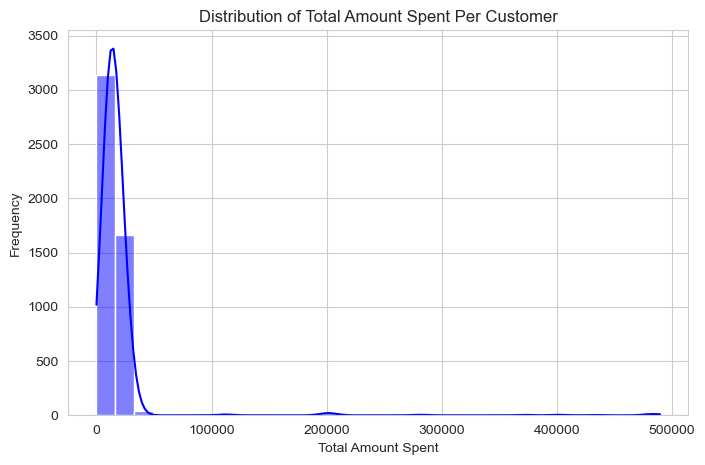

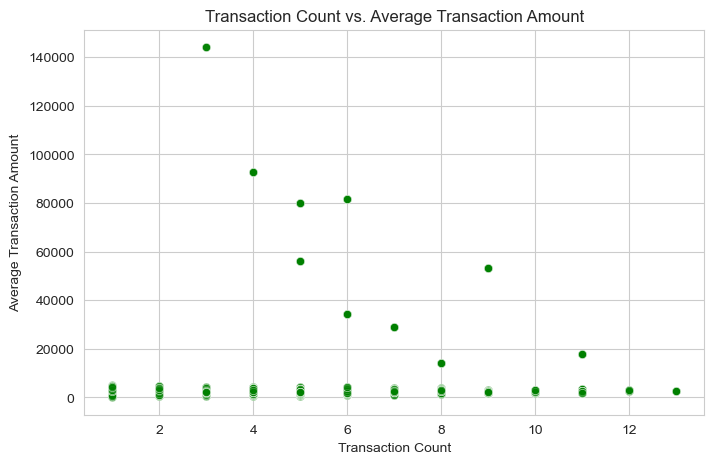

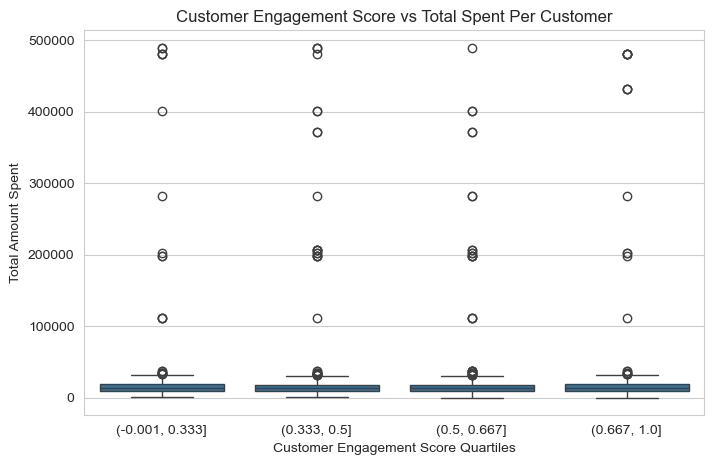

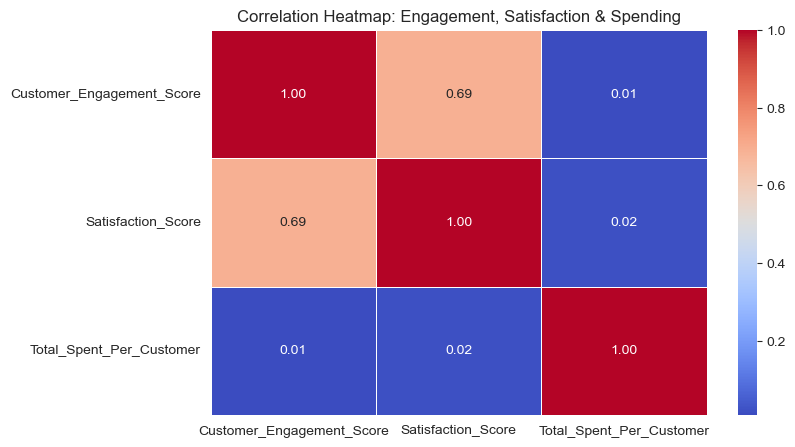

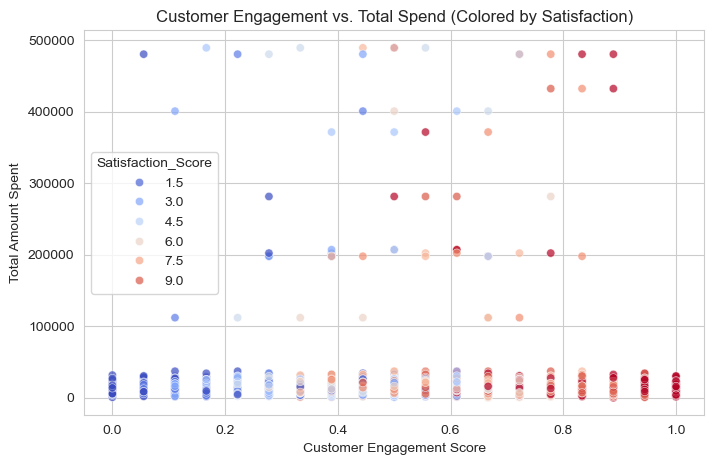

In [149]:
# 📌 Load the datasets
feedback_data = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_feature_engineering.csv')
transaction_data = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_feature_engineering.csv')

# 📌 Drop unique identifiers (we are focusing on behavioral insights)
feedback_data.drop(columns=["Customer_ID"], inplace=True, errors="ignore")
transaction_data.drop(columns=["Transaction_ID", "Customer_ID"], inplace=True, errors="ignore")

# Set seaborn style
sns.set_style("whitegrid")

### 📌 Hypothesis 1: Customers exhibit distinct spending behaviors

# 🔹 Histogram of Total Amount Spent Per Customer
plt.figure(figsize=(8, 5))
sns.histplot(transaction_data["Total_Spent_Per_Customer"], bins=30, kde=True, color="blue")
plt.title("Distribution of Total Amount Spent Per Customer")
plt.xlabel("Total Amount Spent")
plt.ylabel("Frequency")
plt.show()

# 🔹 Scatterplot of Transaction Count vs Average Transaction Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(x=transaction_data["Transaction_Count"], y=transaction_data["Avg_Transaction_Amount"], alpha=0.7, color="green")
plt.title("Transaction Count vs. Average Transaction Amount")
plt.xlabel("Transaction Count")
plt.ylabel("Average Transaction Amount")
plt.show()

### 📌 Hypothesis 2: Customer satisfaction and engagement influence spending behavior

# 🔹 Boxplot: Customer Engagement Score vs Total Spent Per Customer
plt.figure(figsize=(8, 5))
sns.boxplot(x=pd.qcut(feedback_data["Customer_Engagement_Score"], q=4), 
            y=transaction_data["Total_Spent_Per_Customer"])
plt.title("Customer Engagement Score vs Total Spent Per Customer")
plt.xlabel("Customer Engagement Score Quartiles")
plt.ylabel("Total Amount Spent")
plt.show()

# ✅ 🔹 FIXED: Correlation Heatmap of Satisfaction, Engagement, and Spending ✅
# ✅ Merge feedback_data and transaction_data on a common index (not Customer_ID since it's dropped)
corr_df = pd.concat([
    feedback_data[["Customer_Engagement_Score", "Satisfaction_Score"]], 
    transaction_data[["Total_Spent_Per_Customer"]]
], axis=1)

# 🔹 Generate correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Engagement, Satisfaction & Spending")
plt.show()

### 📌 Hypothesis 3: Hidden relationships between demographics, spending, and satisfaction

# 🔹 Clustering customer spending and engagement
plt.figure(figsize=(8, 5))
sns.scatterplot(x=feedback_data["Customer_Engagement_Score"], 
                y=transaction_data["Total_Spent_Per_Customer"], 
                hue=feedback_data["Satisfaction_Score"], palette="coolwarm", alpha=0.7)
plt.title("Customer Engagement vs. Total Spend (Colored by Satisfaction)")
plt.xlabel("Customer Engagement Score")
plt.ylabel("Total Amount Spent")
plt.show()


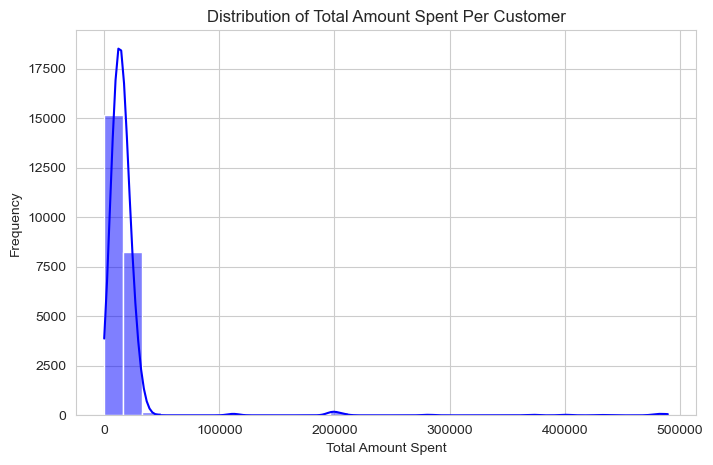

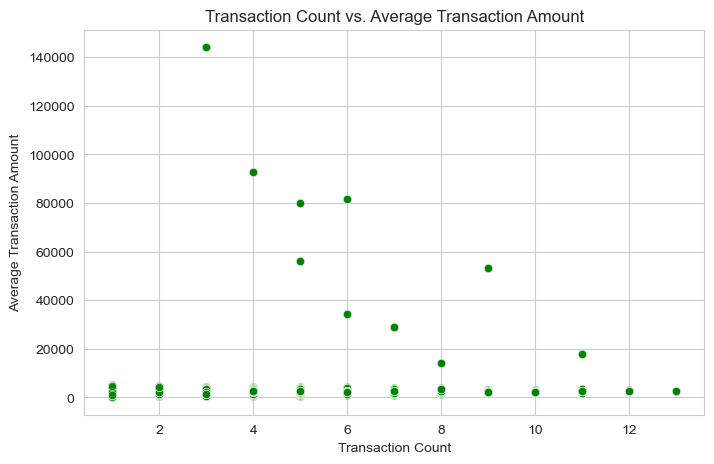

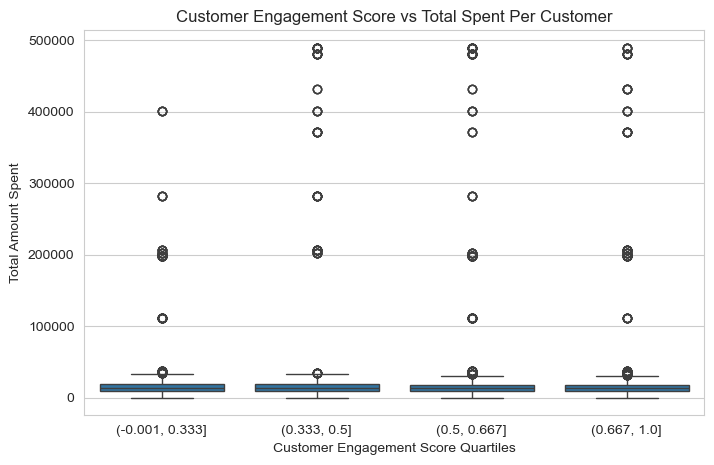

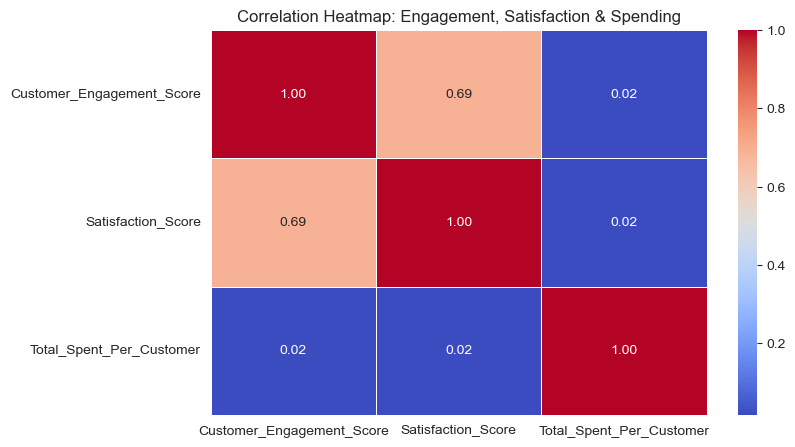

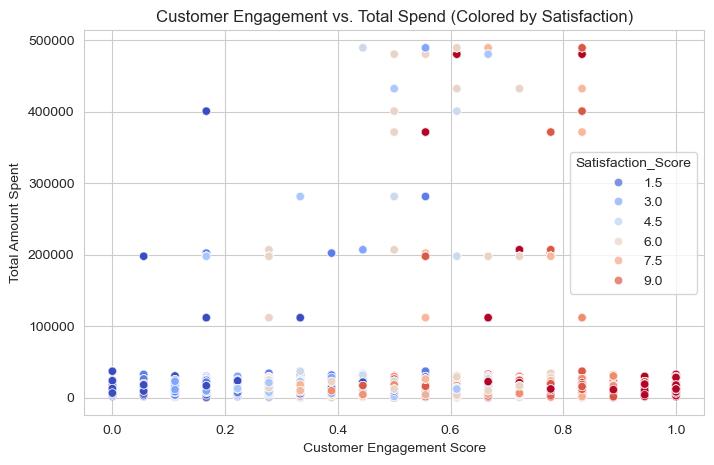

In [43]:
# 📌 Load the feature-engineered datasets
feedback_data = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_feature_engineering.csv')
transaction_data = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_feature_engineering.csv')

# ✅ Temporary merge of datasets for EDA (preserves original feature-engineered files)
merged_data = pd.merge(feedback_data, transaction_data, on="Customer_ID", how="inner")

# 🔹 Drop unique identifiers (no need for analysis)
merged_data.drop(columns=["Customer_ID", "Transaction_ID"], inplace=True, errors="ignore")

# Set seaborn style
sns.set_style("whitegrid")

### 📌 Hypothesis 1: Customers exhibit distinct spending behaviors

# 🔹 Histogram of Total Amount Spent Per Customer
plt.figure(figsize=(8, 5))
sns.histplot(merged_data["Total_Spent_Per_Customer"], bins=30, kde=True, color="blue")
plt.title("Distribution of Total Amount Spent Per Customer")
plt.xlabel("Total Amount Spent")
plt.ylabel("Frequency")
plt.show()

# 🔹 Scatterplot of Transaction Count vs Average Transaction Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(x=merged_data["Transaction_Count"], y=merged_data["Avg_Transaction_Amount"], alpha=0.7, color="green")
plt.title("Transaction Count vs. Average Transaction Amount")
plt.xlabel("Transaction Count")
plt.ylabel("Average Transaction Amount")
plt.show()

### 📌 Hypothesis 2: Customer satisfaction and engagement influence spending behavior

# 🔹 Boxplot: Customer Engagement Score vs Total Spent Per Customer
plt.figure(figsize=(8, 5))
sns.boxplot(x=pd.qcut(merged_data["Customer_Engagement_Score"], q=4), 
            y=merged_data["Total_Spent_Per_Customer"])
plt.title("Customer Engagement Score vs Total Spent Per Customer")
plt.xlabel("Customer Engagement Score Quartiles")
plt.ylabel("Total Amount Spent")
plt.show()

# ✅ 🔹 Correlation Heatmap (Fixed) 🔹 ✅
# ✅ Now using the merged dataset
corr_features = ["Customer_Engagement_Score", "Satisfaction_Score", "Total_Spent_Per_Customer"]
plt.figure(figsize=(8, 5))
sns.heatmap(merged_data[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Engagement, Satisfaction & Spending")
plt.show()

### 📌 Hypothesis 3: Hidden relationships between engagement, satisfaction, and spending

# 🔹 Clustering customer spending and engagement
plt.figure(figsize=(8, 5))
sns.scatterplot(x=merged_data["Customer_Engagement_Score"], 
                y=merged_data["Total_Spent_Per_Customer"], 
                hue=merged_data["Satisfaction_Score"], palette="coolwarm", alpha=0.7)
plt.title("Customer Engagement vs. Total Spend (Colored by Satisfaction)")
plt.xlabel("Customer Engagement Score")
plt.ylabel("Total Amount Spent")
plt.show()


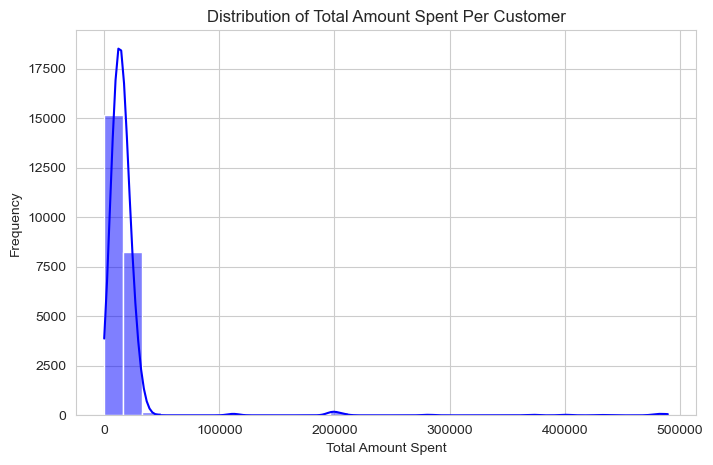

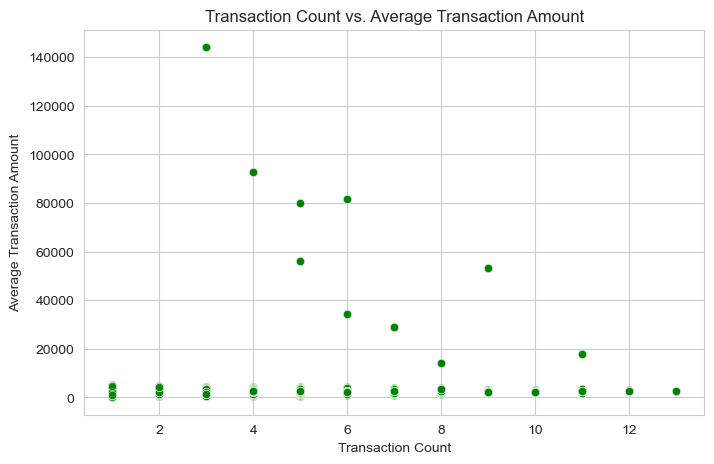

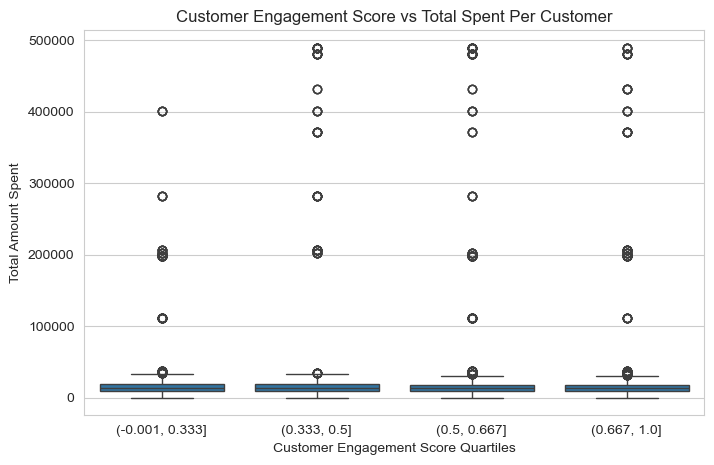

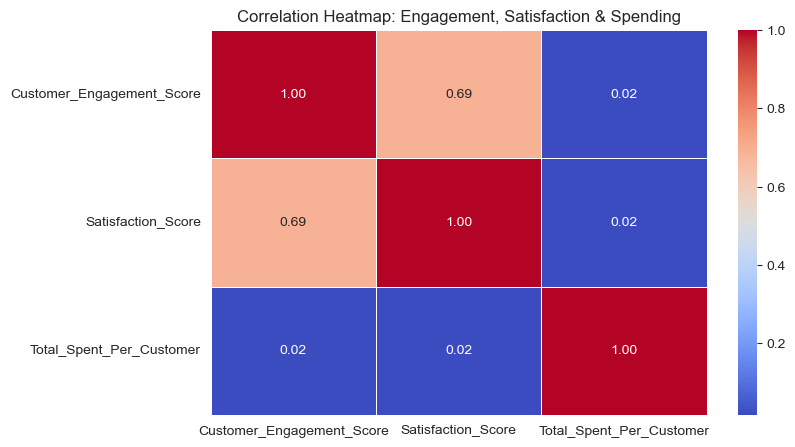

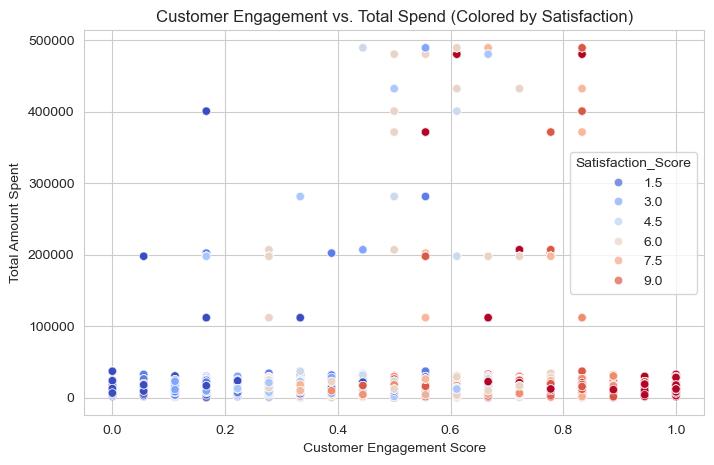

In [65]:
# 📌 Load the feature-engineered datasets
feedback_data = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_feature_engineering.csv')
transaction_data = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_feature_engineering.csv')

# ✅ Temporary merge of datasets for EDA (preserves original feature-engineered files)
merged_data = pd.merge(feedback_data, transaction_data, on="Customer_ID", how="inner")

# 🔹 Drop unique identifiers *AFTER* merging (ensures no unnecessary columns in analysis)
merged_data.drop(columns=["Customer_ID", "Transaction_ID"], inplace=True, errors="ignore")

# Set seaborn style
sns.set_style("whitegrid")

### 📌 Hypothesis 1: Customers exhibit distinct spending behaviors

# 🔹 Histogram of Total Amount Spent Per Customer
plt.figure(figsize=(8, 5))
sns.histplot(merged_data["Total_Spent_Per_Customer"], bins=30, kde=True, color="blue")
plt.title("Distribution of Total Amount Spent Per Customer")
plt.xlabel("Total Amount Spent")
plt.ylabel("Frequency")
plt.show()

# 🔹 Scatterplot of Transaction Count vs Average Transaction Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(x=merged_data["Transaction_Count"], y=merged_data["Avg_Transaction_Amount"], alpha=0.7, color="green")
plt.title("Transaction Count vs. Average Transaction Amount")
plt.xlabel("Transaction Count")
plt.ylabel("Average Transaction Amount")
plt.show()

### 📌 Hypothesis 2: Customer satisfaction and engagement influence spending behavior

# 🔹 Boxplot: Customer Engagement Score vs Total Spent Per Customer
plt.figure(figsize=(8, 5))
sns.boxplot(x=pd.qcut(merged_data["Customer_Engagement_Score"], q=4), 
            y=merged_data["Total_Spent_Per_Customer"])
plt.title("Customer Engagement Score vs Total Spent Per Customer")
plt.xlabel("Customer Engagement Score Quartiles")
plt.ylabel("Total Amount Spent")
plt.show()

# ✅ 🔹 Correlation Heatmap (Fixed) 🔹 ✅
# ✅ Now using the merged dataset
corr_features = ["Customer_Engagement_Score", "Satisfaction_Score", "Total_Spent_Per_Customer"]
plt.figure(figsize=(8, 5))
sns.heatmap(merged_data[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Engagement, Satisfaction & Spending")
plt.show()

### 📌 Hypothesis 3: Hidden relationships between engagement, satisfaction, and spending

# 🔹 Clustering customer spending and engagement
plt.figure(figsize=(8, 5))
sns.scatterplot(x=merged_data["Customer_Engagement_Score"], 
                y=merged_data["Total_Spent_Per_Customer"], 
                hue=merged_data["Satisfaction_Score"], palette="coolwarm", alpha=0.7)
plt.title("Customer Engagement vs. Total Spend (Colored by Satisfaction)")
plt.xlabel("Customer Engagement Score")
plt.ylabel("Total Amount Spent")
plt.show()


# 5. Key Patterns and Insights

#   5.1 Identified Patterns

    5.1.1 High-spending customers tend to have higher satisfaction scores and likelihood to recommend FinMark.

    5.1.2 Investment product users have a distinct transaction pattern compared to credit card users.

    5.1.3 Certain customer groups show low engagement despite frequent transactions, indicating potential dissatisfaction.

#   5.2 Feature Importance

    5.2.1 Transaction Frequency & Amount: Key indicators of customer behavior.

    5.2.2 Satisfaction Score & Likelihood to Recommend: Important for segmenting loyal vs. dissatisfied customers.

    5.2.3 Product Type Preferences: Helps in recommending relevant financial products.